# 실험 0: Baseline

In [1]:
import os
import subprocess

GPU_ID = None  # None이면 아래에서 가장 한가한 GPU를 자동 선택. 고정하려면 "0" / "1" / "2"처럼 지정


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = list(range(10))  # seed 0~9 전부

  GPU 0: memory 15852 MiB, util 96%
  GPU 1: memory 8000 MiB, util 0%
  GPU 2: memory 0 MiB, util 0%
사용 GPU: 2


## 0. 라이브러리 & 공통 유틸 / 모델 정의

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path
_d = Path.cwd().resolve()
while not (_d / "models.py").exists():
    if _d.parent == _d:
        raise FileNotFoundError("상위 폴더 어디에도 models.py가 없습니다")
    _d = _d.parent
if str(_d) not in sys.path:
    sys.path.insert(0, str(_d))
print("공용 모듈 경로:", _d)

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder

from models import Classifier
from utils import (
    set_seed, DEVICE, SEEDS,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from data import build_imbalanced_group_split, crop_group, CachedDataset, CachedSubset

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, data.py)")


공용 모듈 경로: 7_diffusion_image_filter


site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, data.py)


## 1. 데이터 생성: 불균형 데이터셋

In [4]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/AM_image_data_3split")  # 원본 213x460 (한 장을 3조각 낸 k0/k1/k2) → 아래 transform에서 64x64로 resize

RESULTS_CSV = "exp0_baseline.csv"
if os.path.exists(RESULTS_CSV):
    os.remove(RESULTS_CSV)

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_group_split(full_dataset, train_counts, test_counts, seed=seed)
    leaked = ({crop_group(full_dataset.samples[i][0]) for i in train_indices}
              & {crop_group(full_dataset.samples[i][0]) for i in test_indices})
    assert not leaked, f"같은 원본이 train/test에 모두 있음: {sorted(leaked)[:5]}"

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


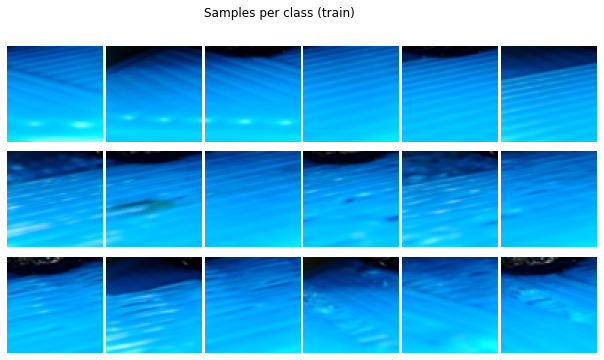

In [5]:
def denorm(x):
    return (x + 1) / 2

W, L, R = 9, 0.13, 0.99
cell = W * (R - L) / 6
H = num_classes * cell + 0.6
fig, axes = plt.subplots(num_classes, 6, figsize=(W, H))
for cls in range(num_classes):
    idxs = [i for i, y in enumerate(train_labels) if y == cls][:6]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[cls, j].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[cls, j].axis("off")
    axes[cls, 0].text(-0.05, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                      ha="right", va="center", fontsize=8)
plt.suptitle("Samples per class (train)")
plt.subplots_adjust(left=L, right=R, bottom=0.05 / H, top=1 - 0.55 / H, wspace=0.03, hspace=0.03)
plt.show()

## 2. 분류기 학습 유틸

In [6]:

CLASSIFIER_EPOCHS_REF = 100
CLASSIFIER_LR = 2e-4
CLASSIFIER_BETAS = (0.5, 0.9)
BASELINE_STEPS = len(train_loader) * CLASSIFIER_EPOCHS_REF
print(f"분류기 학습 기준 step 수 (BASELINE_STEPS) = {len(train_loader)} batches/epoch "
      f"x {CLASSIFIER_EPOCHS_REF} epochs = {BASELINE_STEPS}")

def train_classifier_for_steps(loader, total_steps, seed, tag="Classifier"):
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels, image_size=image_size).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=CLASSIFIER_LR, betas=CLASSIFIER_BETAS)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(loader)
    losses = []
    pbar = tqdm(range(total_steps), desc=f"[{tag} seed{seed}] steps", leave=False)
    t0 = time.time()

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x, y = next(data_iter)

        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        logits = classifier(x)
        loss = cls_loss_fn(logits, y)

        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        pbar.set_postfix(cls=f"{loss.item():.4f}")

        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            print(f"[{tag} seed{seed}] step {step+1}/{total_steps} Cls={np.mean(losses[-50:]):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return classifier


분류기 학습 기준 step 수 (BASELINE_STEPS) = 24 batches/epoch x 100 epochs = 2400


## 실험 0: 베이스라인 (불균형 데이터 그대로 분류)

In [7]:
def run_baseline(seed):
    classifier = train_classifier_for_steps(train_loader, BASELINE_STEPS, seed, tag="Baseline")
    metrics = evaluate_classifier(classifier, test_loader, DEVICE, num_classes, CLASS_NAMES)
    return metrics, classifier


baseline_rows = []
for seed in SEEDS:
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    print(f"\n===== Baseline | Seed {seed} =====")
    t0 = time.time()
    metrics, classifier = run_baseline(seed)
    print(f"[Baseline seed{seed}] 총 소요 시간: {time.time()-t0:.1f}초")


    rows = metrics_to_rows(metrics, seed, "0_baseline_imbalanced")
    baseline_rows.extend(rows)
    append_result_rows(rows, RESULTS_CSV)

df_baseline = pd.DataFrame(baseline_rows)

def seed_summary(df):
    cols = ["precision", "recall", "f1", "accuracy"]
    d = df.assign(**{"class": df["class"].astype(str).replace({str(i): n for i, n in enumerate(CLASS_NAMES)})})
    g = d.groupby(["method", "class"], sort=False)[cols]
    out = g.mean().applymap("{:.3f}".format) + " ± " + g.std(ddof=1).applymap("{:.3f}".format)
    out.insert(0, "n_seeds", g.size())
    return out


display(df_baseline)
print(f"\n===== seed {len(SEEDS)}개 평균 ± 표준편차 =====")
seed_summary(df_baseline)



===== Baseline | Seed 0 =====


[Baseline seed0] steps:  11%|█         | 262/2400 [00:01<00:10, 203.61it/s, cls=0.5834]

[Baseline seed0] step 240/2400 Cls=0.5151 elapsed=1.3s


[Baseline seed0] steps:  21%|██        | 503/2400 [00:02<00:09, 202.09it/s, cls=0.6268]

[Baseline seed0] step 480/2400 Cls=0.4320 elapsed=2.5s


...

[Baseline seed9] step 2160/2400 Cls=0.1672 elapsed=9.8s


[Baseline seed9] step 2400/2400 Cls=0.1536 elapsed=10.8s
===== Evaluation =====
Accuracy        : 0.7900
Precision(macro): 0.8380
Recall(macro)   : 0.7900
F1(macro)       : 0.7823

Per-class:
Class Normal | P:0.634 R:0.970 F1:0.767 N:100
Class Underfill_50FR | P:0.891 R:0.490 F1:0.632 N:100
Class Underfill_Fan | P:0.989 R:0.910 F1:0.948 N:100

Confusion Matrix:
 [[97  3  0]
 [50 49  1]
 [ 6  3 91]]
[Baseline seed9] 총 소요 시간: 10.8초


,method,seed,class,precision,recall,f1,support,accuracy
0,0_baseline_imbalanced,0,0,0.666667,0.960000,0.786885,100,0.793333
1,0_baseline_imbalanced,0,1,0.875000,0.490000,0.628205,100,0.793333
2,0_baseline_imbalanced,0,2,0.930000,0.930000,0.930000,100,0.793333
3,0_baseline_imbalanced,0,macro,0.823889,0.793333,0.781697,300,0.793333
4,0_baseline_imbalanced,1,0,0.573099,0.980000,0.723247,100,0.713333
5,0_baseline_imbalanced,1,1,0.729167,0.350000,0.472973,100,0.713333
6,0_baseline_imbalanced,1,2,1.000000,0.810000,0.895028,100,0.713333
7,0_baseline_imbalanced,1,macro,0.767422,0.713333,0.697083,300,0.713333
8,0_baseline_imbalanced,2,0,0.645833,0.930000,0.762295,100,0.780000
9,0_baseline_imbalanced,2,1,0.849057,0.450000,0.588235,100,0.780000



===== seed 10개 평균 ± 표준편차 =====


n_seeds      precision         recall  \
method                class                                                   
0_baseline_imbalanced Normal               10  0.622 ± 0.039  0.979 ± 0.021   
                      Underfill_50FR       10  0.892 ± 0.074  0.393 ± 0.097   
                      Underfill_Fan        10  0.949 ± 0.030  0.927 ± 0.046   
                      macro                10  0.821 ± 0.031  0.766 ± 0.037   

                                                 f1       accuracy  
method                class                                         
0_baseline_imbalanced Normal          0.760 ± 0.028  0.766 ± 0.037  
                      Underfill_50FR  0.539 ± 0.104  0.766 ± 0.037  
                      Underfill_Fan   0.936 ± 0.020  0.766 ± 0.037  
                      macro           0.745 ± 0.047  0.766 ± 0.037